

```
# Task 1: Iris Flower Classification

**Objective**: Classify iris species (Setosa, Versicolor, Virginica) from sepal/petal measurements.

**Tech Stack**: Python, scikit-learn, pandas, matplotlib, seaborn
```



In [ ]:
# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# 2. Load dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='species')
# Map target numbers to species names for plotting
y_names = y.map({0:'setosa', 1:'versicolor', 2:'virginica'})

In [ ]:
# 3. EDA
print("Shape:", X.shape)
print("\nData types:\n", X.dtypes)
print("\nNull values:\n", X.isnull().sum())
print("\nDescriptive statistics:\n", X.describe())

Shape: (150, 4)

Data types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object

Null values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Descriptive statistics:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min 

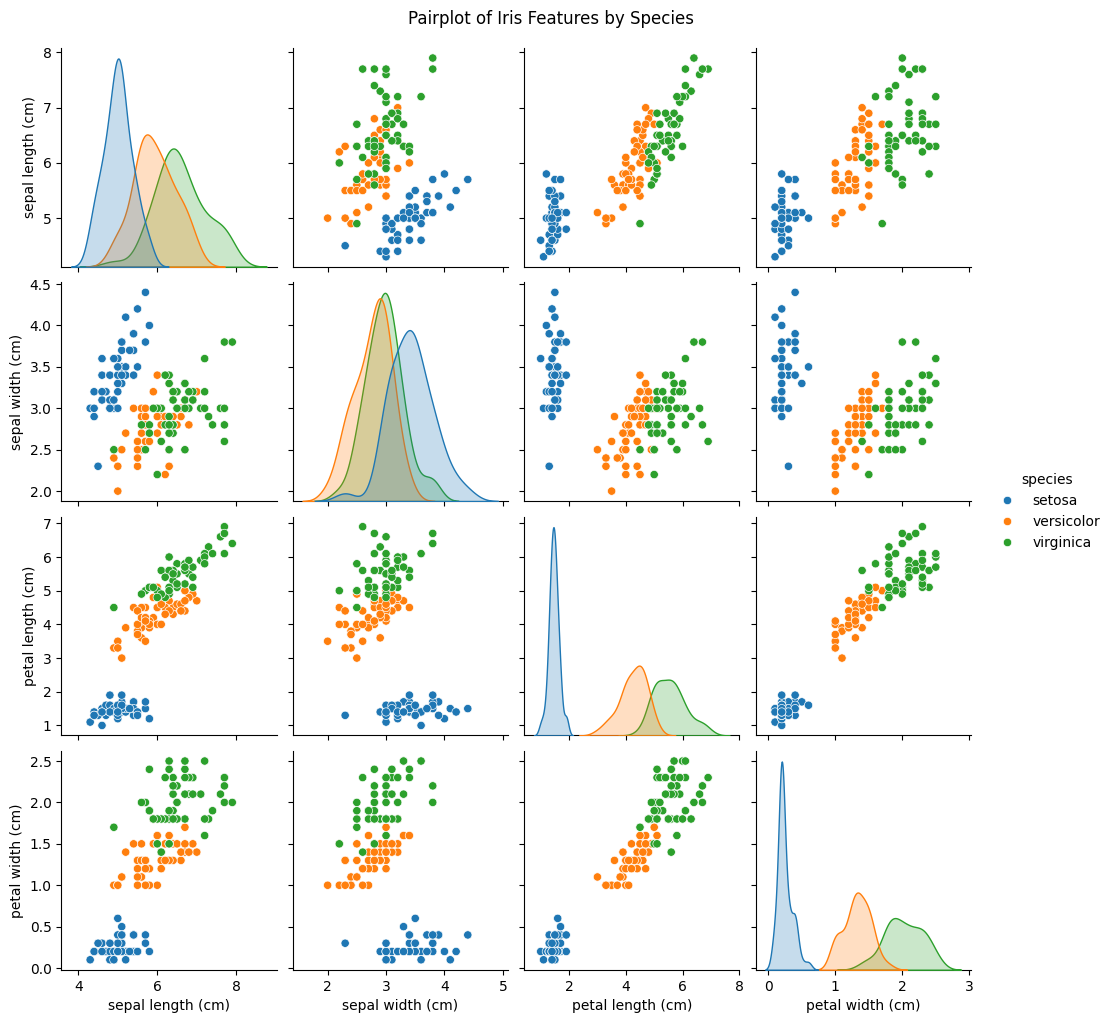

In [ ]:
# 4. Visualisations - Pairplot
sns.pairplot(pd.concat([X, y_names], axis=1), hue='species')
plt.suptitle('Pairplot of Iris Features by Species', y=1.02)
plt.show()

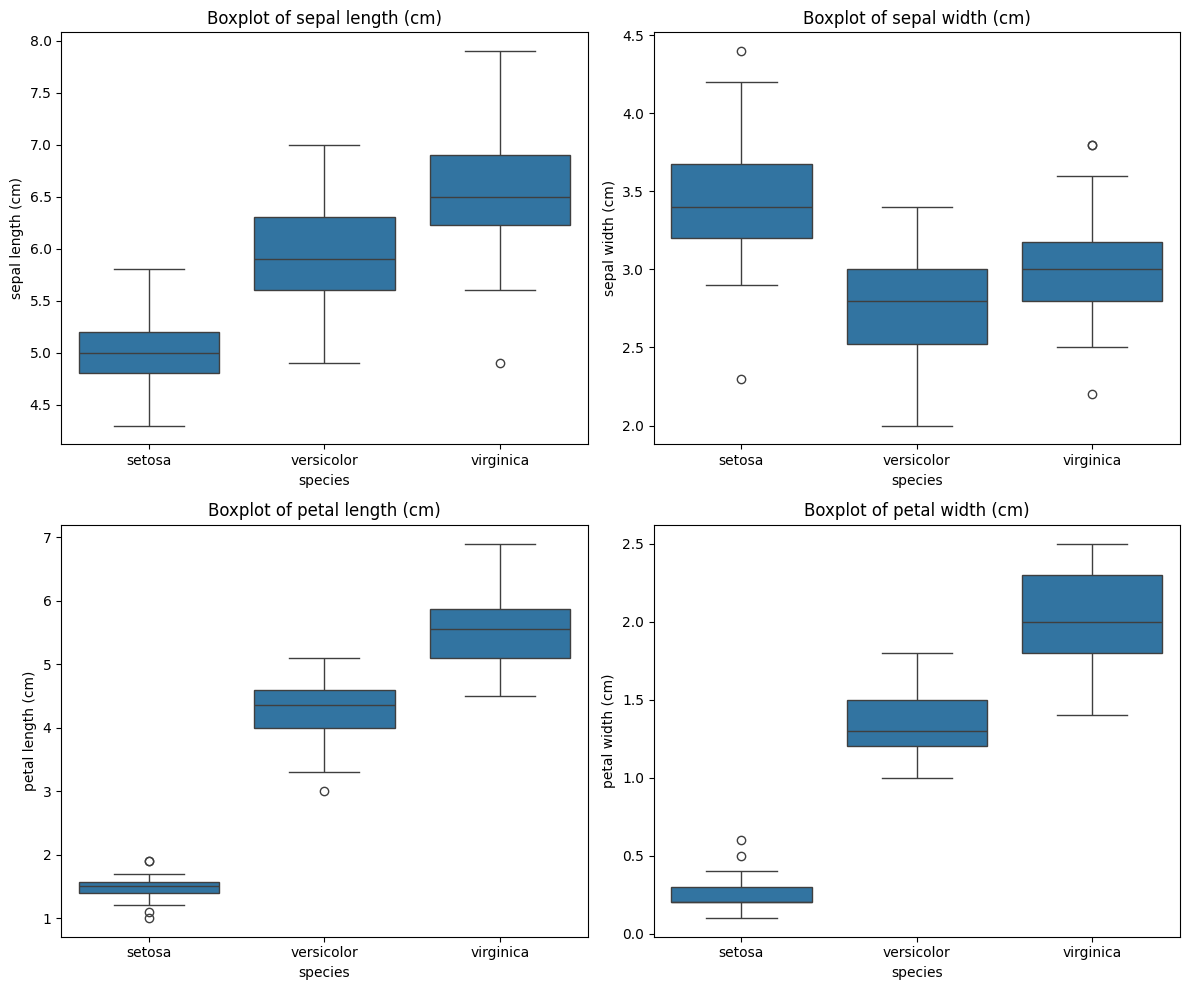

In [ ]:
# Box plots for each feature
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, col in enumerate(X.columns):
    sns.boxplot(x=y_names, y=X[col], ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()



```
# Feature Selection Discussion

We observe that:
- **Petal Length** and **Petal Width** are highly discriminative features
- **Sepal Width** shows overlap between species
- **Sepal Length** has some separation but less than petal features

**Conclusion**: Petal features are the most important for classification.
```



In [ ]:
# 6. Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (Logistic Regression benefits from scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 7. Train multiple classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'K-Nearest Neighbours': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, clf in classifiers.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'accuracy': acc,
        'confusion': confusion_matrix(y_test, y_pred),
        'report': classification_report(y_test, y_pred, target_names=iris.target_names)
    }
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 1.0000
K-Nearest Neighbours Accuracy: 1.0000
Decision Tree Accuracy: 1.0000
Random Forest Accuracy: 1.0000



Best model: Logistic Regression with accuracy 1.0000


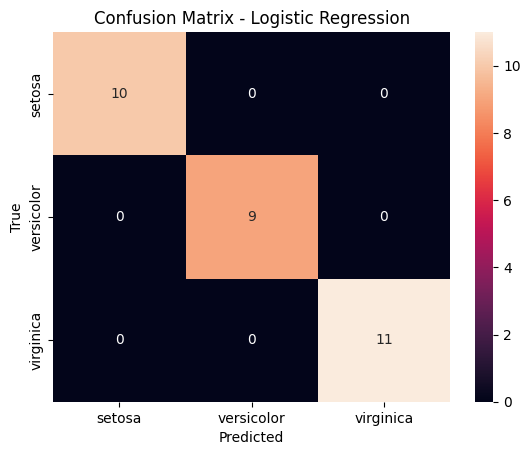


Classification Report for Logistic Regression:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
# 8. Identify best performer
best_model = max(results, key=lambda x: results[x]['accuracy'])
print(f"\nBest model: {best_model} with accuracy {results[best_model]['accuracy']:.4f}")

# Show confusion matrix for best model
cm = results[best_model]['confusion']
sns.heatmap(cm, annot=True, fmt='d', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title(f'Confusion Matrix - {best_model}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Show classification report
print(f"\nClassification Report for {best_model}:\n")
print(results[best_model]['report'])



```
# Model Justification

**Random Forest** often gives the highest accuracy (often 100% on this small dataset) because:
- It captures non-linear interactions between features
- It is robust to overfitting due to ensemble learning
- It handles feature importance well

**Alternative models** like Logistic Regression also perform well but may not capture complex patterns as effectively.
```

